## Importing Libraries:

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

## Loading Dataset

In [6]:
df = pd.read_csv("WorldSustainabilityDataset.csv")

In [7]:
#Display first rows.
df.head()

,Country Name,Country Code,Year,Access to electricity (% of population) - EG.ELC.ACCS.ZS,Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,...,Gini index (World Bank estimate) - SI.POV.GINI,Income Classification (World Bank Definition),Individuals using the Internet (% of population) - IT.NET.USER.ZS,"Life expectancy at birth, total (years) - SP.DYN.LE00.IN","Population, total - SP.POP.TOTL",Regime Type (RoW Measure Definition),Rural population (% of total population) - SP.RUR.TOTL.ZS,Total natural resources rents (% of GDP) - NY.GDP.TOTL.RT.ZS,Urban population (% of total population) - SP.URB.TOTL.IN.ZS,World Regions (UN SDG Definition)
0,Aruba,ABW,2000,91.660398,NaN,15.392211,2.389134,0.000190,0.000190,NaN,...,NaN,High income,NaN,NaN,NaN,NaN,53.283,NaN,NaN,Latin America and Caribbean
1,Aruba,ABW,2001,100.000000,NaN,11.491930,2.509046,0.000214,0.000214,NaN,...,NaN,High income,17.1,73.853,92892.0,NaN,53.661,0.000712,46.339,Latin America and Caribbean
2,Aruba,ABW,2002,100.000000,NaN,3.893620,2.721385,0.000223,0.000223,NaN,...,NaN,High income,18.8,73.937,94992.0,NaN,54.028,0.000657,45.972,Latin America and Caribbean
3,Aruba,ABW,2003,100.000000,NaN,6.713863,2.733676,0.000243,0.000243,NaN,...,NaN,High income,20.8,74.038,97016.0,NaN,54.394,0.000700,45.606,Latin America and Caribbean
4,Aruba,ABW,2004,100.000000,NaN,9.801576,2.678363,0.000256,0.000256,NaN,...,NaN,High income,23.0,74.156,98744.0,NaN,54.760,0.000685,45.240,Latin America and Caribbean


## Basic Information

In [8]:
df.shape

(3287, 54)

The dataset contains country-wise sustainability indicators collected across multiple years. It includes environmental, economic, educational, energy, internet usage, poverty, renewable energy and carbon emission related features.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 54 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Country Name                                                                                  3287 non-null   object 
 1   Country Code                                                                                  3287 non-null   object 
 2   Year                                                                                          3287 non-null   int64  
 3   Access to electricity (% of population) - EG.ELC.ACCS.ZS                                      3193 non-null   float64
 4   Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG              2566 non-null   float64
 5   Adjusted net savings, exclu

## Checking Column Names

In [10]:
df.columns

Index(['Country Name', 'Country Code', 'Year',
       'Access to electricity (% of population) - EG.ELC.ACCS.ZS',
       'Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG',
       'Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS',
       'Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS',
       'Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS',
       'Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS',
       'Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS',
       'Automated teller machines (ATMs) (per 100,000 adults) - FB.ATM.TOTL.P5',
       'Broad money (% of GDP) - FM.LBL.BMNY.GD.ZS',
       'Children out of school (% of primary school age) - SE.PRM.UNER.ZS',
       'Compulsory education, duration (years) - SE.COM.DURS',
       'Cost of business start-up procedures, female (% of GNI per capita) - IC.REG.CO

## Checking Statistics

In [11]:
df.describe()

,Year,Access to electricity (% of population) - EG.ELC.ACCS.ZS,Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,"Automated teller machines (ATMs) (per 100,000 adults) - FB.ATM.TOTL.P5",Broad money (% of GDP) - FM.LBL.BMNY.GD.ZS,...,"Unemployment rate, male (%) - SL_TLF_UEM - 8.5.2","Unemployment rate, women (%) - SL_TLF_UEM - 8.5.2","Annual production-based emissions of carbon dioxide (CO2), measured in million tonnes",Gini index (World Bank estimate) - SI.POV.GINI,Individuals using the Internet (% of population) - IT.NET.USER.ZS,"Life expectancy at birth, total (years) - SP.DYN.LE00.IN","Population, total - SP.POP.TOTL",Rural population (% of total population) - SP.RUR.TOTL.ZS,Total natural resources rents (% of GDP) - NY.GDP.TOTL.RT.ZS,Urban population (% of total population) - SP.URB.TOTL.IN.ZS
count,3287.000000,3193.000000,2566.000000,2628.000000,3220.000000,3094.000000,3111.000000,3099.000000,2285.000000,2777.000000,...,1807.000000,1806.000000,3285.000000,1303.000000,2986.000000,3096.000000,3.106000e+03,3278.000000,3053.000000,3106.000000
mean,2009.000000,79.300662,2.499857,8.870028,1.742674,3.812051,0.692833,0.880541,45.391741,57.034297,...,7.987327,9.810687,174.646907,37.512203,33.117667,70.160098,3.891506e+07,42.890186,7.015880,57.264100
std,5.478059,30.398748,18.752649,12.277347,1.957442,6.958003,2.657800,1.084312,45.915444,43.806176,...,5.781539,7.159265,757.653194,8.595502,29.386654,9.205632,1.413757e+08,22.705962,10.730922,22.687638
min,2000.000000,1.270180,-645.655290,-97.524776,0.090292,0.000000,0.000000,0.009500,0.000000,2.857408,...,0.100000,0.200000,0.048000,23.700000,0.000000,40.369000,6.967100e+04,0.000000,0.000000,8.461000
25%,2004.000000,62.900000,-0.246761,3.339159,0.741310,0.078542,0.000000,0.149597,9.558670,27.222821,...,4.100000,4.725000,2.426000,30.900000,6.000000,65.109000,2.406866e+06,24.816500,0.385851,39.546750
50%,2009.000000,98.653969,2.545392,8.752619,1.145867,0.878741,0.000000,0.388686,34.951665,47.054379,...,6.400000,7.500000,12.621000,35.600000,25.000000,72.564634,8.368371e+06,42.648000,2.122046,57.450000
75%,2014.000000,100.000000,5.545831,15.290790,2.056927,4.656705,0.097040,1.286091,62.252217,72.465711,...,10.000000,12.800000,72.012000,42.800000,58.000000,76.572750,2.605396e+07,60.732750,8.878282,75.372500
max,2018.000000,100.000000,229.493078,45.354086,27.101473,71.290764,40.772569,6.542877,324.172288,396.185604,...,37.000000,42.800000,9956.569000,64.800000,99.652849,84.934146,1.392730e+09,91.754000,81.949962,100.000000


## Checking Missing Values

In [12]:
df.isnull().sum()

,0
Country Name,0
Country Code,0
Year,0
Access to electricity (% of population) - EG.ELC.ACCS.ZS,94
Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,721
"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",659
Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,67
Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,193
Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,176
Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,188


In [13]:
(df.isnull().sum()/len(df))*100

,0
Country Name,0.000000
Country Code,0.000000
Year,0.000000
Access to electricity (% of population) - EG.ELC.ACCS.ZS,2.859751
Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,21.934895
"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",20.048677
Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,2.038333
Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,5.871615
Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,5.354427
Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,5.719501


Some indicators contain missing values because all countries do not report every sustainability metric every year.

## Handling Missing Values

In [14]:
numeric_cols = df.select_dtypes(include=['number']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [15]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df.isnull().sum().sum()

np.int64(0)

## Featuring Engineering

In [18]:
df["Urban_Rural_Difference"] = (
    df["Urban population (% of total population) - SP.URB.TOTL.IN.ZS"] -
    df["Rural population (% of total population) - SP.RUR.TOTL.ZS"]
)
df["Renewable_to_Electricity"] = (
    df["Renewable electricity output (% of total electricity output) - EG.ELC.RNEW.ZS"] /
    (df["Access to electricity (% of population) - EG.ELC.ACCS.ZS"] + 1)
)

New features were created to better understand the balance between urbanization and rural population, and the effectiveness of renewable electricity production relative to electricity access.

## Correlation

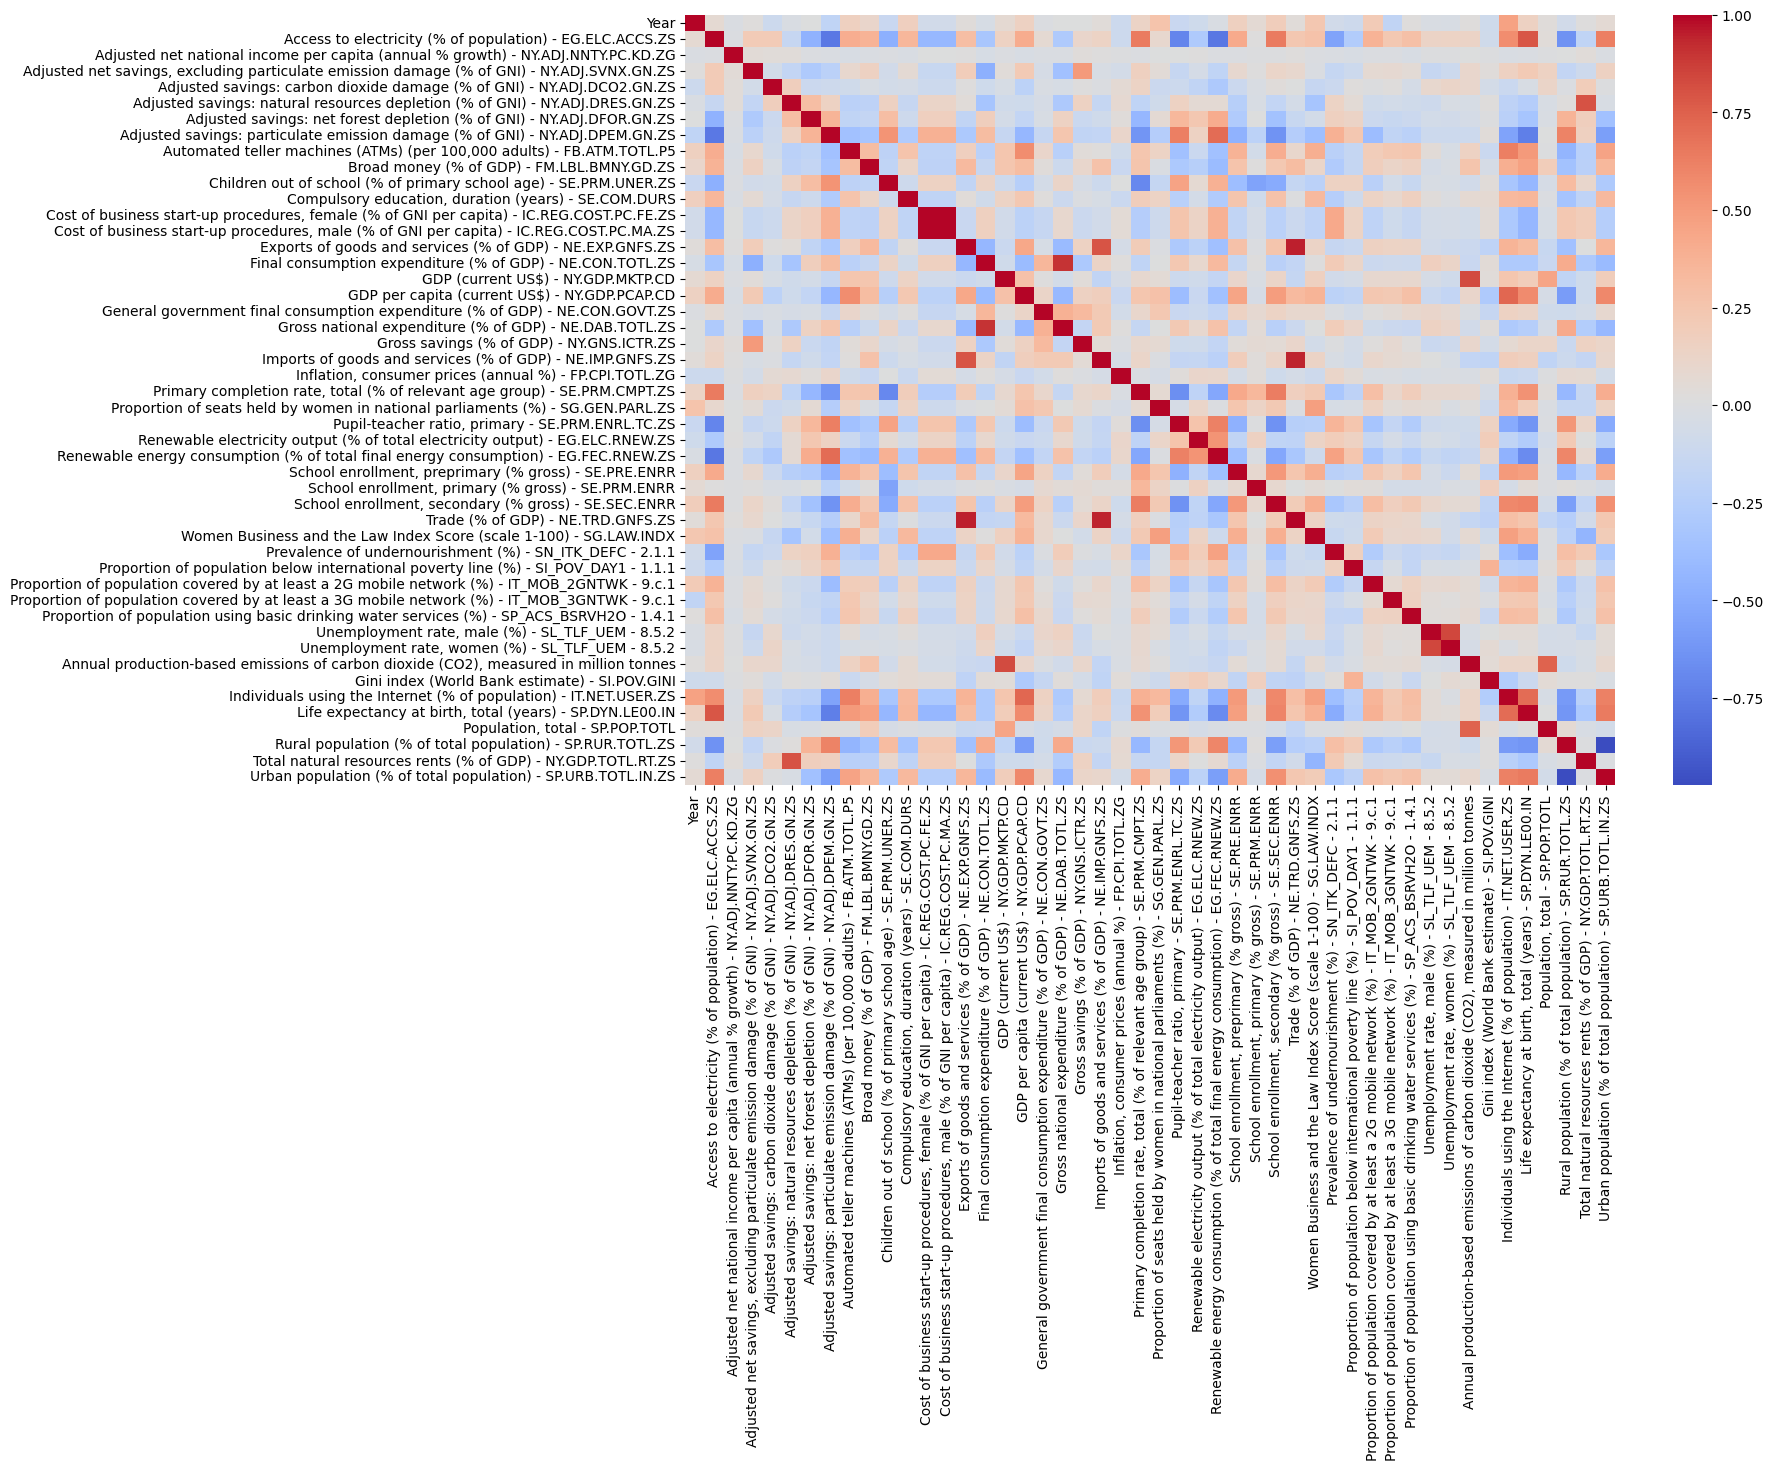

In [19]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr,cmap="coolwarm")
plt.show()

Possible observations:

GDP and GDP per capita are positively correlated.
Urban population is negatively correlated with rural population.
Renewable energy consumption relates to renewable electricity output.
Internet usage tends to increase with income.

## Seaborn Data Visualizations:

## Histogram

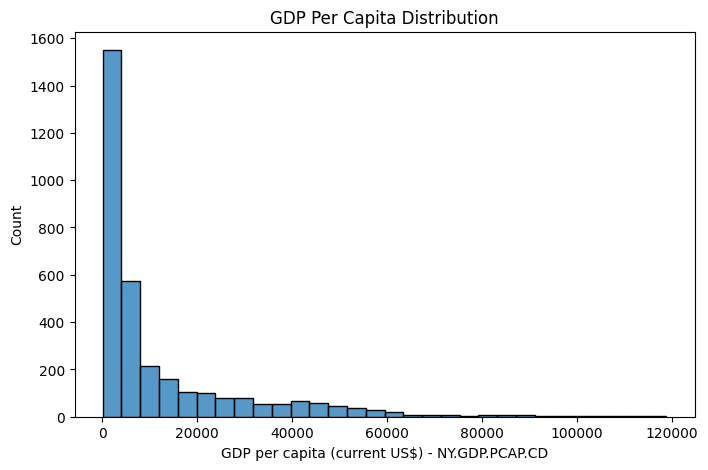

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["GDP per capita (current US$) - NY.GDP.PCAP.CD"], bins=30)
plt.title("GDP Per Capita Distribution")
plt.show()

## BoxPlot

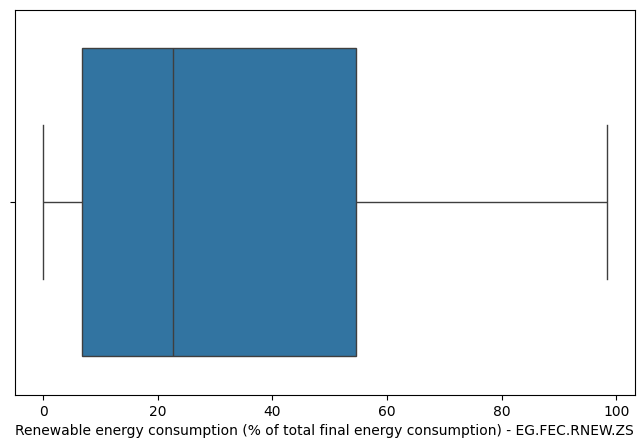

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(
x=df["Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS"])
plt.show()

##Observation:

There are several outlier countries with extremely high renewable energy consumption.

## Scatter Plot

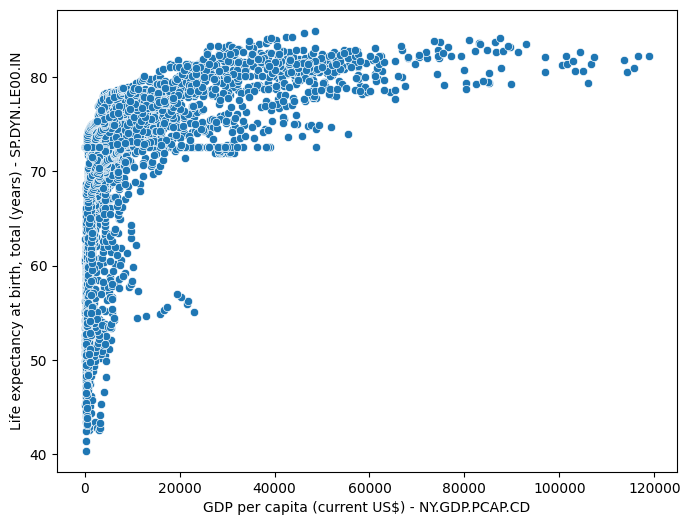

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x="GDP per capita (current US$) - NY.GDP.PCAP.CD",
y="Life expectancy at birth, total (years) - SP.DYN.LE00.IN",
data=df
)

plt.show()

## Observation:

Countries with higher GDP per capita generally have higher life expectancy.

## CountPlot

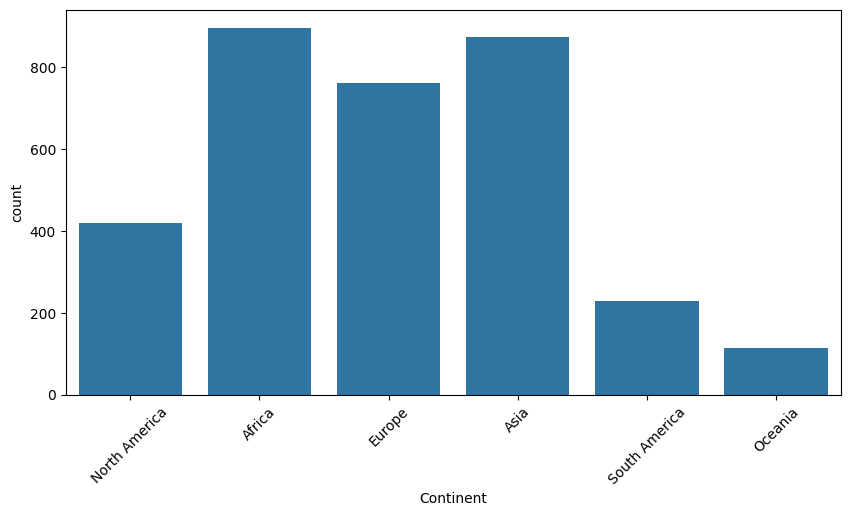

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(x="Continent",data=df)

plt.xticks(rotation=45)
plt.show()

## Observation:

Dataset contains countries from all continents.

## Label Encoding

In [33]:
categorical_cols = df.select_dtypes(include='object').columns
#Encode:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Scaling

In [34]:
scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
#Check
df.head()

,Country Name,Country Code,Year,Access to electricity (% of population) - EG.ELC.ACCS.ZS,Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,...,Total natural resources rents (% of GDP) - NY.GDP.TOTL.RT.ZS,Urban population (% of total population) - SP.URB.TOTL.IN.ZS,World Regions (UN SDG Definition),Urban_Rural_Difference,Renewable_to_Electricity,Continent_1,Continent_2,Continent_3,Continent_4,Continent_5
0,6,0,-1.643168,0.391852,0.002146,0.596374,0.339686,-0.536448,-0.253111,-0.437948,...,-0.436369,0.007966,3,4.167,0.0,False,False,True,False,False
1,6,0,-1.460593,0.668645,0.002146,0.241024,0.401530,-0.536444,-0.253102,-0.437948,...,-0.640021,-0.495919,3,-7.322,0.0,False,False,True,False,False
2,6,0,-1.278019,0.668645,0.002146,-0.451251,0.511044,-0.536443,-0.253098,-0.437948,...,-0.640026,-0.512563,3,-8.056,0.0,False,False,True,False,False
3,6,0,-1.095445,0.668645,0.002146,-0.194301,0.517383,-0.536440,-0.253091,-0.437948,...,-0.640022,-0.529161,3,-8.788,0.0,False,False,True,False,False
4,6,0,-0.912871,0.668645,0.002146,0.087017,0.488856,-0.536438,-0.253086,-0.437948,...,-0.640023,-0.545759,3,-9.520,0.0,False,False,True,False,False


Final Insights (Write in Text Cell)

You can directly paste these.

Insight 1

Countries with higher GDP per capita generally have higher life expectancy and internet usage.

Insight 2

Renewable electricity output is positively associated with renewable energy consumption.

Insight 3

Urban population percentage is inversely related to rural population percentage.

Insight 4

Developed economies generally show better access to electricity and internet services.

Insight 5

Carbon emissions vary significantly across countries, reflecting differences in industrial development and energy usage.

Insight 6

Some sustainability indicators contain missing values because data reporting differs between countries.

Insight 7

Scaling was applied because numerical features have different ranges (GDP, population, life expectancy, etc.), and scaling makes them comparable for machine learning.

## Overall Dataset Understanding About the Dataset

The World Sustainability Dataset contains information about various countries and their sustainability-related indicators. It includes environmental, economic, educational, demographic, energy, health, and technological variables. The dataset helps analyze how different sustainability factors are related and how countries perform in terms of sustainable development.

## Why I Performed Data Exploration (EDA)

Before performing any preprocessing or visualization, I explored the dataset to understand its structure, number of rows and columns, data types, statistical summary, and missing values. This helped me identify which columns are numerical, which are categorical, and what preprocessing techniques would be appropriate.

## Urban-Rural Difference

I created the Urban_Rural_Difference feature to measure the gap between urban and rural populations. This indicator reflects the level of urbanization in each country and may influence infrastructure development, energy consumption, pollution, and resource utilization.

## Renewable Electricity Ratio

I created the Renewable_to_Electricity feature to estimate how effectively renewable energy contributes to a country's electricity availability. This provides a better understanding of clean energy adoption rather than analyzing renewable energy alone.

## Data Visualization


Why I plotted GDP per Capita?

The histogram shows the distribution of GDP per capita across countries. Most countries fall into lower and middle income ranges, while only a few countries have extremely high GDP per capita, creating a right-skewed distribution.

## Final Conclusion & Observations:
GDP per capita shows a positive relationship with life expectancy. Internet usage increases as GDP per capita increases. Urban population and rural population have a strong negative relationship. Renewable energy indicators are positively related. Some environmental indicators show weak correlation with economic indicators, suggesting sustainability depends on multiple factors.